# Attention head — plots

Visualizes everything `train_attention_head.py` reports:

- **`comparison_results/attention_head_summary.csv`** — mean train/val MSE & PCC, plus per-trait MSE/PCC.
- **`comparison_results/attention_head_detail.npz`** — per-epoch MSE curves (`train_hist`, `val_hist`), predictions (`pred_train`, `pred_test`), targets (`y_train`, `y_test`), `trait_cols`.

Run `python train_attention_head.py` first to (re)generate those files.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

RESULTS_DIR = Path("comparison_results")
summary = pd.read_csv(RESULTS_DIR / "attention_head_summary.csv")
detail  = np.load(RESULTS_DIR / "attention_head_detail.npz", allow_pickle=True)

train_hist = detail["train_hist"]      # (epochs, n_traits) MSE
val_hist   = detail["val_hist"]
pred_train = detail["pred_train"]      # (n, n_traits)
pred_test  = detail["pred_test"]
y_train    = detail["y_train"]
y_test     = detail["y_test"]
trait_cols = [str(t) for t in detail["trait_cols"]]

# Per-trait scalars from the summary row.
row       = summary.iloc[0]
train_mse = np.array([row[f"Train_{t}_mse"] for t in trait_cols])
val_mse   = np.array([row[f"Val_{t}_mse"]   for t in trait_cols])
train_pcc = np.array([row[f"Train_{t}_pcc"] for t in trait_cols])
val_pcc   = np.array([row[f"Val_{t}_pcc"]   for t in trait_cols])

print(summary[["Model", "Train MSE Mean", "Val MSE Mean", "Train PCC Mean", "Val PCC Mean"]].to_string(index=False))
print(f"\nhist {train_hist.shape}  preds(test) {pred_test.shape}  traits {len(trait_cols)}")

         Model  Train MSE Mean  Val MSE Mean  Train PCC Mean  Val PCC Mean
Attention_head          1.0032        0.9715          0.0031        0.0171

hist (50, 36)  preds(test) (39, 36)  traits 36


## Plotting utilities

In [2]:
def _grid(n):
    ncol = int(np.ceil(np.sqrt(n)))
    nrow = int(np.ceil(n / ncol))
    return nrow, ncol


def plot_mean_curves(train_hist, val_hist):
    """Mean-across-traits MSE per epoch, train vs val."""
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(train_hist.mean(axis=1), label="train")
    ax.plot(val_hist.mean(axis=1), "--", label="val")
    ax.set_xlabel("epoch"); ax.set_ylabel("mean masked MSE")
    ax.set_title("Mean MSE over epochs"); ax.legend()
    fig.tight_layout(); plt.show()


def plot_trait_curves(train_hist, val_hist, trait_cols):
    """Small-multiples: per-trait MSE over epochs (solid=train, dashed=val)."""
    n = len(trait_cols)
    nrow, ncol = _grid(n)
    fig, axes = plt.subplots(nrow, ncol, figsize=(2.8 * ncol, 2.0 * nrow), squeeze=False)
    for k in range(nrow * ncol):
        ax = axes[k // ncol][k % ncol]
        if k < n:
            ax.plot(train_hist[:, k])
            ax.plot(val_hist[:, k], "--")
            ax.set_title(trait_cols[k], fontsize=7)
            ax.tick_params(labelsize=6)
        else:
            ax.axis("off")
    fig.suptitle("Per-trait MSE over epochs (solid=train, dashed=val)", y=1.002)
    fig.tight_layout(); plt.show()


def plot_metric_bars(labels, train_vals, val_vals, ylabel, title):
    """Grouped train/val bars per trait, sorted by val."""
    order = np.argsort(np.nan_to_num(val_vals, nan=-np.inf))[::-1]
    x = np.arange(len(labels)); w = 0.4
    fig, ax = plt.subplots(figsize=(max(8, 0.4 * len(labels)), 4))
    ax.bar(x - w / 2, np.asarray(train_vals)[order], w, label="train")
    ax.bar(x + w / 2, np.asarray(val_vals)[order],   w, label="val")
    ax.set_xticks(x); ax.set_xticklabels(np.asarray(labels)[order], rotation=90, fontsize=7)
    ax.set_ylabel(ylabel); ax.set_title(title); ax.legend()
    fig.tight_layout(); plt.show()


def plot_pred_vs_actual(pred, targ, trait_cols, split=""):
    """Small-multiples scatter of predicted vs actual per trait, NaN-masked."""
    n = len(trait_cols)
    nrow, ncol = _grid(n)
    fig, axes = plt.subplots(nrow, ncol, figsize=(2.8 * ncol, 2.6 * nrow), squeeze=False)
    for k in range(nrow * ncol):
        ax = axes[k // ncol][k % ncol]
        if k >= n:
            ax.axis("off"); continue
        m = ~np.isnan(targ[:, k]) & ~np.isnan(pred[:, k])
        if m.sum() == 0:
            ax.axis("off"); continue
        t, p = targ[m, k], pred[m, k]
        ax.scatter(t, p, s=10, alpha=0.6, linewidths=0)
        lo, hi = min(t.min(), p.min()), max(t.max(), p.max())
        ax.plot([lo, hi], [lo, hi], "k--", lw=0.7)
        if m.sum() > 1 and t.std() > 0 and p.std() > 0:
            r = np.corrcoef(t, p)[0, 1]
            ax.set_title(f"{trait_cols[k]}\nr={r:.2f}", fontsize=7)
        else:
            ax.set_title(trait_cols[k], fontsize=7)
        ax.tick_params(labelsize=6)
    fig.suptitle(f"Predicted vs actual{' — ' + split if split else ''}", y=1.002)
    fig.tight_layout(); plt.show()

## Learning curves

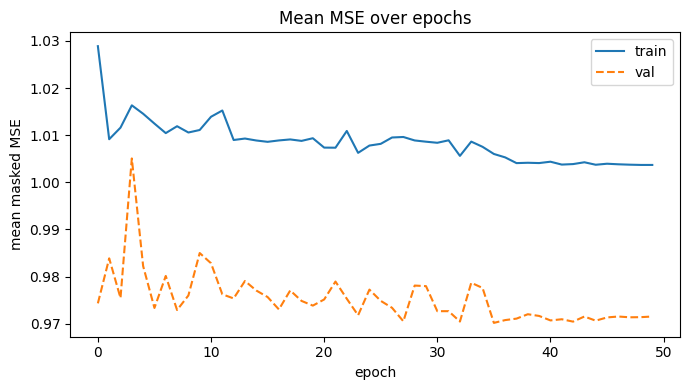

In [3]:
plot_mean_curves(train_hist, val_hist)

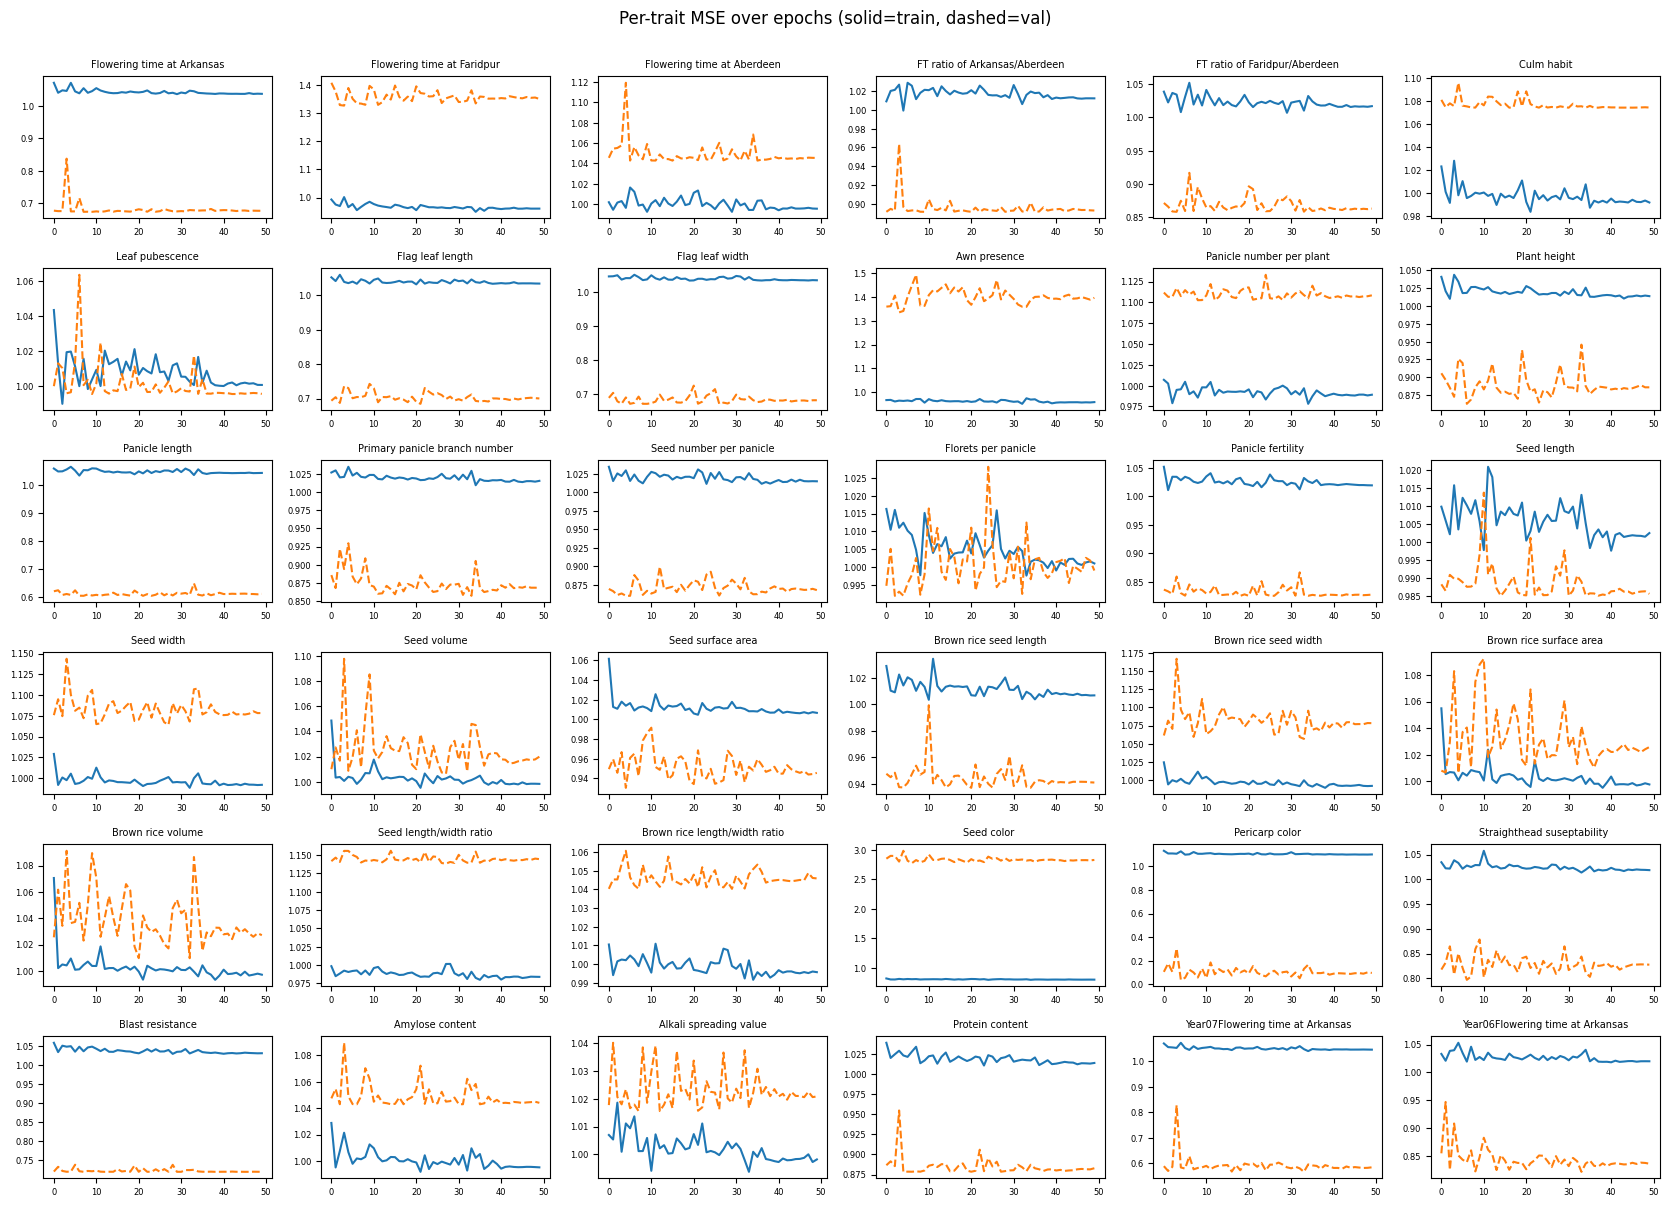

In [4]:
plot_trait_curves(train_hist, val_hist, trait_cols)

## Per-trait metrics (train vs val)

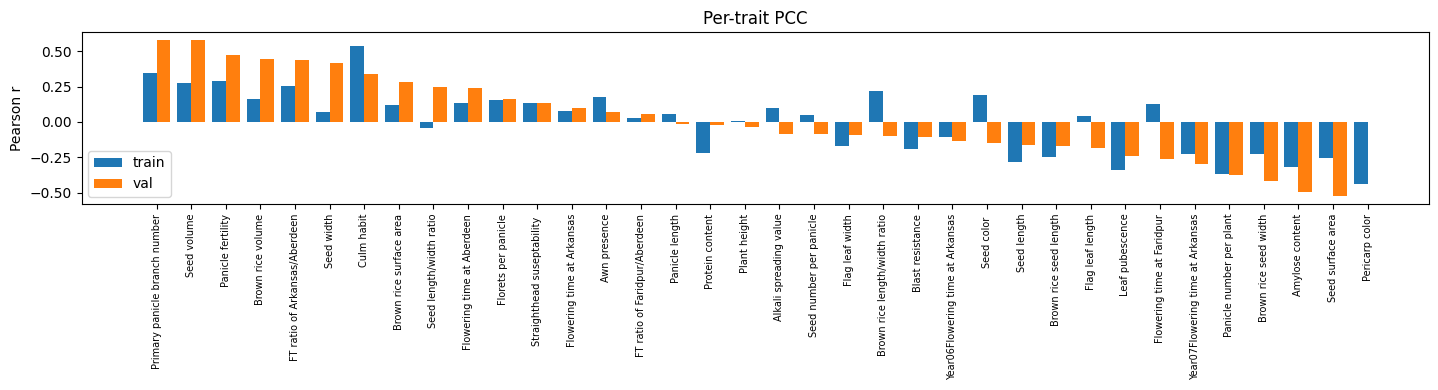

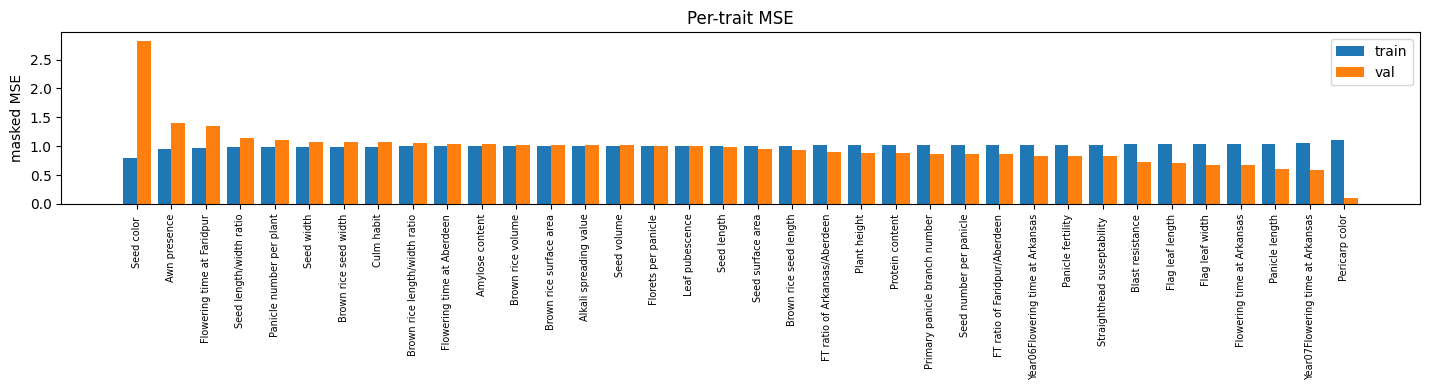

In [5]:
plot_metric_bars(trait_cols, train_pcc, val_pcc, "Pearson r", "Per-trait PCC")
plot_metric_bars(trait_cols, train_mse, val_mse, "masked MSE", "Per-trait MSE")

## Predicted vs actual

In [ ]:
plot_pred_vs_actual(pred_test,  y_test,  trait_cols, split="validation")
plot_pred_vs_actual(pred_train, y_train, trait_cols, split="train")